# Neural Networks for Regression and Classfication

A neural network is a function that maps an input vector $\mathbf{x}$ to an output vector $\mathbf{y}$, learning from data.

$$
\hat{\mathbf{y}} = f(\mathbf{x}; \Theta)
$$

- $\mathbf{x}$: input features  
- $\hat{\mathbf{y}}$: predicted output  
- $\Theta$: all trainable parameters (weights and biases)

The network learns to approximate an unknown true function $y = g(x)$ by adjusting $\Theta$.

A network consists of layers, each made of neurons.

Each neuron computes:

$$
z = \mathbf{w}^T \mathbf{x} + b,\quad a = \sigma(z)
$$

- $\mathbf{w}$: weight vector for inputs  
- $b$: bias term  
- $\sigma(z)$: activation function, e.g., sigmoid, ReLU, or tanh.


**Example: A Single Hidden Layer**

We want a neural network that maps an input $x$ to a scalar output $\hat{y}$ using **one hidden layer** with an activation function $\sigma$.

**Model Definition**

Let:

$$
\hat{y} = W^{[2]} \, \sigma \big( W^{[1]} x + b^{[1]} \big) + b^{[2]}
$$

- $W^{[1]}$: weight for input to hidden layer  
- $b^{[1]}$: bias for hidden layer  
- $W^{[2]}$: weight for hidden to output  
- $b^{[2]}$: output bias  
- $\sigma(\cdot)$: non-linear activation function (e.g., sigmoid or tanh)

**Loss Function**

Given a true label $y$, the **Mean Squared Error** is:

$$
L = \frac{1}{2} (\hat{y} - y)^2.
$$

**Optimization Goal**

Minimize $L$ w.r.t. all trainable parameters.

**Derivates (because, we use Gradient Descent for optimization)**

**Output:**  
$\hat{y} = W^{[2]} \, \sigma(z) + b^{[2]}$  
where $z = W^{[1]} x + b^{[1]}$.

**Derivative w.r.t. $W^{[2]}$**

$$
\frac{\partial L}{\partial W^{[2]}}
= (\hat{y} - y) \cdot \sigma(z).
$$

**Derivative w.r.t. $b^{[2]}$**

$$
\frac{\partial L}{\partial b^{[2]}}
= (\hat{y} - y).
$$

**Derivative w.r.t. $W^{[1]}$**

Chain rule:

$$
\frac{\partial L}{\partial W^{[1]}}
= (\hat{y} - y) \cdot W^{[2]} \cdot \sigma'(z) \cdot x.
$$

**Derivative w.r.t. $b^{[1]}$**

$$
\frac{\partial L}{\partial b^{[1]}}
= (\hat{y} - y) \cdot W^{[2]} \cdot \sigma'(z).
$$

Where:

$$
\sigma'(z) =
\begin{cases}
\sigma(z)(1 - \sigma(z)) & \text{if sigmoid} \\
1 - \tanh^2(z) & \text{if tanh}
\end{cases}
$$

**Update Rules**

Gradient Descent step for learning rate $\eta$:

$$
\begin{cases}
W^{[2]} := W^{[2]} - \eta \frac{\partial L}{\partial W^{[2]}} \\
b^{[2]} := b^{[2]} - \eta \frac{\partial L}{\partial b^{[2]}} \\
W^{[1]} := W^{[1]} - \eta \frac{\partial L}{\partial W^{[1]}} \\
b^{[1]} := b^{[1]} - \eta \frac{\partial L}{\partial b^{[1]}}
\end{cases}.
$$

**From Equations to Code**

For a single hidden layer network:

$$
\hat{y} = W^{[2]} \, \sigma(W^{[1]} x + b^{[1]}) + b^{[2]}
$$

the gradients are:

- $\frac{\partial L}{\partial W^{[2]}} = (\hat{y} - y) \, \sigma(z)$  
- $\frac{\partial L}{\partial b^{[2]}} = (\hat{y} - y)$  
- $\frac{\partial L}{\partial W^{[1]}} = (\hat{y} - y) W^{[2]} \sigma'(z) x$  
- $\frac{\partial L}{\partial b^{[1]}} = (\hat{y} - y) W^{[2]} \sigma'(z)$

where $z = W^{[1]} x + b^{[1]}$.

In code, these appear exactly as:

- `grad_W2 = error * hidden`
- `grad_b2 = error`
- `grad_W1 = error * W2 * sigma_prime * x`
- `grad_b1 = error * W2 * sigma_prime`

Below is a direct implementation of these updates for a toy regression problem.

Epoch 0, Loss: 0.302652
Epoch 1000, Loss: 0.038944
Epoch 2000, Loss: 0.024905
Epoch 3000, Loss: 0.017647
Epoch 4000, Loss: 0.014495
Epoch 5000, Loss: 0.012515
Epoch 6000, Loss: 0.011052
Epoch 7000, Loss: 0.009922
Epoch 8000, Loss: 0.009030
Epoch 9000, Loss: 0.008314


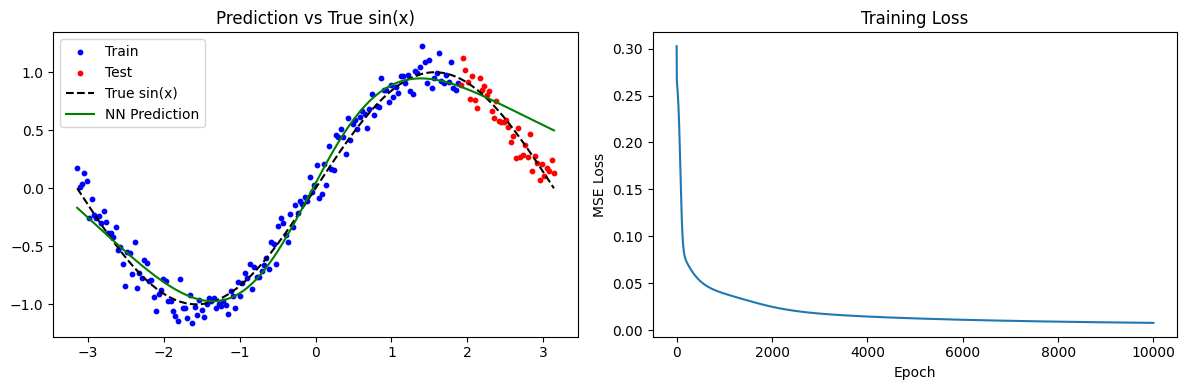

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Generate sin(x) data with noise ---
np.random.seed(0)
X_all = np.linspace(-np.pi, np.pi, 200).reshape(1, -1)  # shape (1, N)
Y_true = np.sin(X_all)
noise = np.random.normal(0, 0.1, size=Y_true.shape)
Y_all = Y_true + noise

# Train/test split
split_idx = int(0.8 * X_all.shape[1])
X_train = X_all[:, :split_idx]  # shape (1, N_train)
Y_train = Y_all[:, :split_idx]

X_test = X_all[:, split_idx:]
Y_test = Y_all[:, split_idx:]

# --- 2. Define network: more hidden neurons ---
n_input = 1
n_hidden = 10   # more hidden neurons!
n_output = 1

W1 = np.random.randn(n_hidden, n_input) * 0.1  # shape (n_hidden, 1)
b1 = np.zeros((n_hidden, 1))

W2 = np.random.randn(n_output, n_hidden) * 0.1  # shape (1, n_hidden)
b2 = np.zeros((n_output, 1))

# Activation
def sigmoid(Z):
    return 1 / (1 + np.exp(-Z))

def sigmoid_derivative(A):
    return A * (1 - A)

# --- 3. Training ---
lr = 0.1
epochs = 10000
losses = []

N = X_train.shape[1]

for epoch in range(epochs):
    # Forward
    Z1 = np.dot(W1, X_train) + b1  # (n_hidden, N)
    A1 = sigmoid(Z1)               # (n_hidden, N)
    Z2 = np.dot(W2, A1) + b2       # (1, N)
    Y_hat = Z2

    # Loss
    error = Y_hat - Y_train
    loss = np.mean(0.5 * error ** 2)
    losses.append(loss)

    # Backward
    dZ2 = error  # (1, N)
    dW2 = np.dot(dZ2, A1.T) / N    # (1, n_hidden)
    db2 = np.mean(dZ2, axis=1, keepdims=True)  # (1,1)

    dA1 = np.dot(W2.T, dZ2)        # (n_hidden, N)
    dZ1 = dA1 * sigmoid_derivative(A1)  # (n_hidden, N)
    dW1 = np.dot(dZ1, X_train.T) / N  # (n_hidden, 1)
    db1 = np.mean(dZ1, axis=1, keepdims=True)  # (n_hidden, 1)

    # Update
    W2 -= lr * dW2
    b2 -= lr * db2
    W1 -= lr * dW1
    b1 -= lr * db1

    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.6f}")

# --- 4. Predictions ---
Z1_all = np.dot(W1, X_all) + b1
A1_all = sigmoid(Z1_all)
Y_hat_all = np.dot(W2, A1_all) + b2

# --- 5. Plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: prediction
axes[0].scatter(X_train.flatten(), Y_train.flatten(), color='blue', s=10, label='Train')
axes[0].scatter(X_test.flatten(), Y_test.flatten(), color='red', s=10, label='Test')
axes[0].plot(X_all.flatten(), Y_true.flatten(), 'k--', label='True sin(x)')
axes[0].plot(X_all.flatten(), Y_hat_all.flatten(), 'g-', label='NN Prediction')
axes[0].set_title("Prediction vs True sin(x)")
axes[0].legend()

# Right: loss
axes[1].plot(losses)
axes[1].set_title("Training Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE Loss")

plt.tight_layout()
plt.show()

## Binary Classification — Single Hidden Layer Neural Network

**Problem Statement**

Given input $x$ and binary label $y \in \{0, 1\}$,  
the goal is to predict $\hat{y}$, the probability that $y = 1$.

**Model**

A neural network with **one hidden layer**:

$$
\hat{y} = \sigma \Big( W^{[2]} \, \sigma(W^{[1]} x + b^{[1]}) + b^{[2]} \Big)
$$

where:

- $W^{[1]}$: input-to-hidden weights
- $b^{[1]}$: hidden bias
- $W^{[2]}$: hidden-to-output weights
- $b^{[2]}$: output bias
- $\sigma(z) = \frac{1}{1 + e^{-z}}$: sigmoid function

**Loss Function: Binary Cross-Entropy**

For one sample:

$$
L = - \big[ y \log(\hat{y}) + (1 - y) \log(1 - \hat{y}) \big].
$$

**Forward Pass**

1. Hidden pre-activation:  
   $z^{[1]} = W^{[1]} x + b^{[1]}$

2. Hidden activation:  
   $a^{[1]} = \sigma(z^{[1]})$

3. Output pre-activation:  
   $z^{[2]} = W^{[2]} a^{[1]} + b^{[2]}$

4. Predicted probability:  
   $\hat{y} = \sigma(z^{[2]})$

**Derivatives**

**Output layer:**

- The derivative of BCE loss for sigmoid output simplifies to:

$$
\frac{\partial L}{\partial z^{[2]}} = \hat{y} - y.
$$

- Gradient w.r.t. output weights:

$$
\frac{\partial L}{\partial W^{[2]}} = (\hat{y} - y) a^{[1]}.
$$

- Gradient w.r.t. output bias:

$$
\frac{\partial L}{\partial b^{[2]}} = \hat{y} - y.
$$

**Hidden layer:**

- Backprop to hidden activation:

$$
\frac{\partial L}{\partial a^{[1]}} = (\hat{y} - y) W^{[2]}.
$$

- Backprop through sigmoid:

$$
\frac{\partial L}{\partial z^{[1]}} = \frac{\partial L}{\partial a^{[1]}} \cdot \sigma'(z^{[1]}) 
= (\hat{y} - y) W^{[2]} \, a^{[1]} (1 - a^{[1]}).
$$

- Gradient w.r.t. input weights:

$$
\frac{\partial L}{\partial W^{[1]}} = \frac{\partial L}{\partial z^{[1]}} \, x.
$$

- Gradient w.r.t. hidden bias:

$$
\frac{\partial L}{\partial b^{[1]}} = \frac{\partial L}{\partial z^{[1]}}.
$$

**Update Rules**

For learning rate $\eta$:

$$
\begin{cases}
W^{[2]} := W^{[2]} - \eta (\hat{y} - y) a^{[1]} \\[6pt]
b^{[2]} := b^{[2]} - \eta (\hat{y} - y) \\[6pt]
W^{[1]} := W^{[1]} - \eta (\hat{y} - y) W^{[2]} a^{[1]} (1 - a^{[1]}) x \\[6pt]
b^{[1]} := b^{[1]} - \eta (\hat{y} - y) W^{[2]} a^{[1]} (1 - a^{[1]}).
\end{cases}
$$

**Summary**

- Input $x$ → hidden layer with sigmoid → output layer with sigmoid → $\hat{y}$
- Loss: Binary cross-entropy.
- Backprop: chain rule through output and hidden layer.
- Updates: standard SGD.

This is the **standard MLP** for binary classification, exactly matching classic problems like **XOR**.

**Next**

We will now implement this for the **XOR** dataset using **NumPy** with the same logic.

Epoch 0, Loss: 0.693220
Epoch 1000, Loss: 0.693147
Epoch 2000, Loss: 0.693147
Epoch 3000, Loss: 0.693147
Epoch 4000, Loss: 0.693146
Epoch 5000, Loss: 0.693145
Epoch 6000, Loss: 0.693135
Epoch 7000, Loss: 0.666789
Epoch 8000, Loss: 0.013412
Epoch 9000, Loss: 0.005604


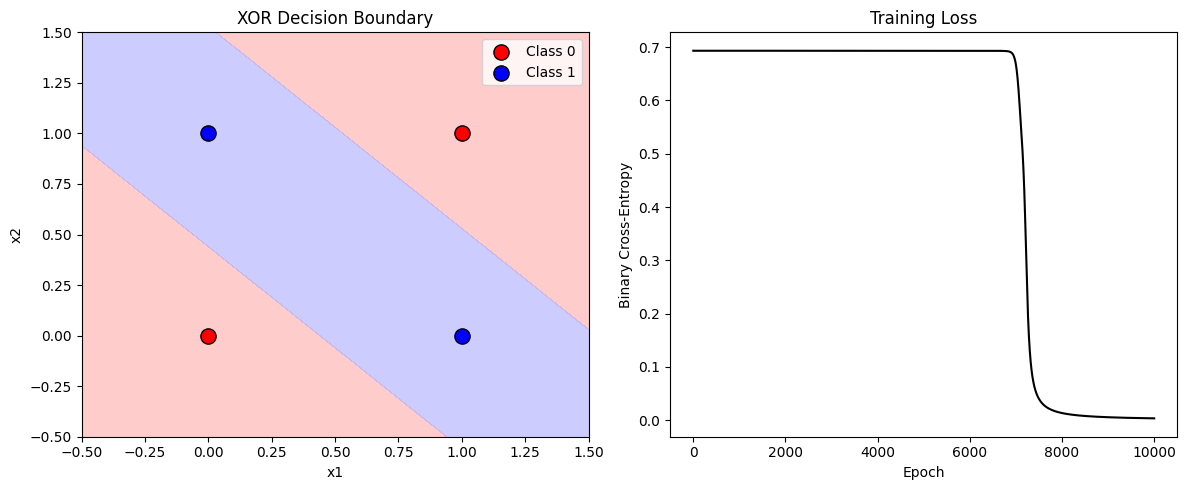

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. XOR data ---
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
]).T  # shape (2, 4)

Y = np.array([[0, 1, 1, 0]])  # shape (1, 4)

# --- 2. Network ---
np.random.seed(42)
n_input = 2
n_hidden = 2
n_output = 1

W1 = np.random.randn(n_hidden, n_input) * 0.1
b1 = np.zeros((n_hidden, 1))

W2 = np.random.randn(n_output, n_hidden) * 0.1
b2 = np.zeros((n_output, 1))

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(a):
    return a * (1 - a)

# --- 3. Train ---
lr = 1.0
epochs = 10000
losses = []

N = X.shape[1]

for epoch in range(epochs):
    # Forward
    Z1 = np.dot(W1, X) + b1
    A1 = sigmoid(Z1)

    Z2 = np.dot(W2, A1) + b2
    Y_hat = sigmoid(Z2)

    # Loss
    loss = -np.mean(Y * np.log(Y_hat + 1e-8) + (1 - Y) * np.log(1 - Y_hat + 1e-8))
    losses.append(loss)

    # Backward
    dZ2 = Y_hat - Y
    dW2 = np.dot(dZ2, A1.T) / N
    db2 = np.mean(dZ2, axis=1, keepdims=True)

    dA1 = np.dot(W2.T, dZ2)
    dZ1 = dA1 * sigmoid_derivative(A1)
    dW1 = np.dot(dZ1, X.T) / N
    db1 = np.mean(dZ1, axis=1, keepdims=True)

    W2 -= lr * dW2
    b2 -= lr * db2
    W1 -= lr * dW1
    b1 -= lr * db1

    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.6f}")

# --- 4. Grid for decision boundary ---
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
grid = np.c_[xx.ravel(), yy.ravel()].T  # shape (2, N_points)

# Predict on grid
Z1_grid = np.dot(W1, grid) + b1
A1_grid = sigmoid(Z1_grid)
Z2_grid = np.dot(W2, A1_grid) + b2
Y_grid = sigmoid(Z2_grid).reshape(xx.shape)

# --- 5. Subplots ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: decision boundary + points
axes[0].contourf(xx, yy, Y_grid, levels=[0, 0.5, 1], alpha=0.6, colors=['#FFAAAA', '#AAAAFF'])
for i in range(4):
    if Y[0, i] == 0:
        axes[0].scatter(X[0, i], X[1, i], color='red', edgecolor='k', s=120, label='Class 0' if i == 0 else "")
    else:
        axes[0].scatter(X[0, i], X[1, i], color='blue', edgecolor='k', s=120, label='Class 1' if i == 1 else "")
axes[0].set_title("XOR Decision Boundary")
axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")
axes[0].legend()

# Right: loss curve
axes[1].plot(losses, color='black')
axes[1].set_title("Training Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Binary Cross-Entropy")

plt.tight_layout()
plt.show()

# Multi-Class Classification — Single Hidden Layer Neural Network

Given:
- Input feature vector $x$
- True label $y \in \{1, 2, ..., K\}$

Goal:
- Predict a probability vector $\hat{y} \in [0, 1]^K$ where $\sum_{k=1}^K \hat{y}_k = 1$

**Model**

A single hidden layer neural network:

1. Hidden layer:

$$
z^{[1]} = W^{[1]} x + b^{[1]} \quad (\text{shape: } (H, 1))
$$

$$
a^{[1]} = \sigma(z^{[1]})
$$

1. Output layer logits:

$$
z^{[2]} = W^{[2]} a^{[1]} + b^{[2]} \quad (\text{shape: } (K, 1))
$$

1. Output probabilities (softmax):

$$
\hat{y}_k = \frac{\exp(z^{[2]}_k)}{\sum_{j=1}^K \exp(z^{[2]}_j)}
$$

**Loss Function: Categorical Cross-Entropy**

For one-hot encoded true label vector $y$:

$$
L = - \sum_{k=1}^K y_k \log(\hat{y}_k)
$$

**Forward Pass Summary**

- Input $x$ → hidden linear transform → nonlinearity → output linear transform → softmax → $\hat{y}$
- Softmax maps raw scores to valid probability distribution.

**Gradients — Output Layer**

**Key identity** (softmax + cross-entropy):

The gradient of cross-entropy loss w.r.t. the logits $z^{[2]}$ is:

$$
\frac{\partial L}{\partial z^{[2]}_k} = \hat{y}_k - y_k.
$$

So,

$$
\frac{\partial L}{\partial z^{[2]}} = \hat{y} - y.
$$

**Gradients for output weights and bias:**

$$
\frac{\partial L}{\partial W^{[2]}} = (\hat{y} - y) \, a^{[1]^T}
$$

$$
\frac{\partial L}{\partial b^{[2]}} = \hat{y} - y
$$

**Gradients — Hidden Layer**

Backpropagate to hidden activations:

$$
\frac{\partial L}{\partial a^{[1]}} = W^{[2]^T} (\hat{y} - y)
$$

Backprop through the hidden activation function:

$$
\frac{\partial L}{\partial z^{[1]}} = \frac{\partial L}{\partial a^{[1]}} \odot \sigma'(z^{[1]})
$$

where $\sigma'(z) = \sigma(z) (1 - \sigma(z))$ for sigmoid.

Gradients for input weights and bias:

$$
\frac{\partial L}{\partial W^{[1]}} = \left( \frac{\partial L}{\partial z^{[1]}} \right) x^T
$$

$$
\frac{\partial L}{\partial b^{[1]}} = \frac{\partial L}{\partial z^{[1]}}
$$

**Update Rules**

For learning rate $\eta$:

$$
\begin{cases}
W^{[2]} := W^{[2]} - \eta \frac{\partial L}{\partial W^{[2]}} \\[6pt]
b^{[2]} := b^{[2]} - \eta \frac{\partial L}{\partial b^{[2]}} \\[6pt]
W^{[1]} := W^{[1]} - \eta \frac{\partial L}{\partial W^{[1]}} \\[6pt]
b^{[1]} := b^{[1]} - \eta \frac{\partial L}{\partial b^{[1]}}
\end{cases}
$$

**Summary**

- Softmax + cross-entropy gives a **very clean gradient**: $\hat{y} - y$.
- Hidden layer backprop uses standard chain rule with the activation derivative.
- Updates follow standard SGD.
- This setup works for **multi-class classification** like MNIST digits or any $K$-class problem.

We will now implement this derivation for a simple synthetic **3-class classification** problem using **NumPy**.

Epoch 0, Loss: 1.098657
Epoch 1000, Loss: 0.403227
Epoch 2000, Loss: 0.154313
Epoch 3000, Loss: 0.104489
Epoch 4000, Loss: 0.083643
Epoch 5000, Loss: 0.071140
Epoch 6000, Loss: 0.062449
Epoch 7000, Loss: 0.055961
Epoch 8000, Loss: 0.050866
Epoch 9000, Loss: 0.046713


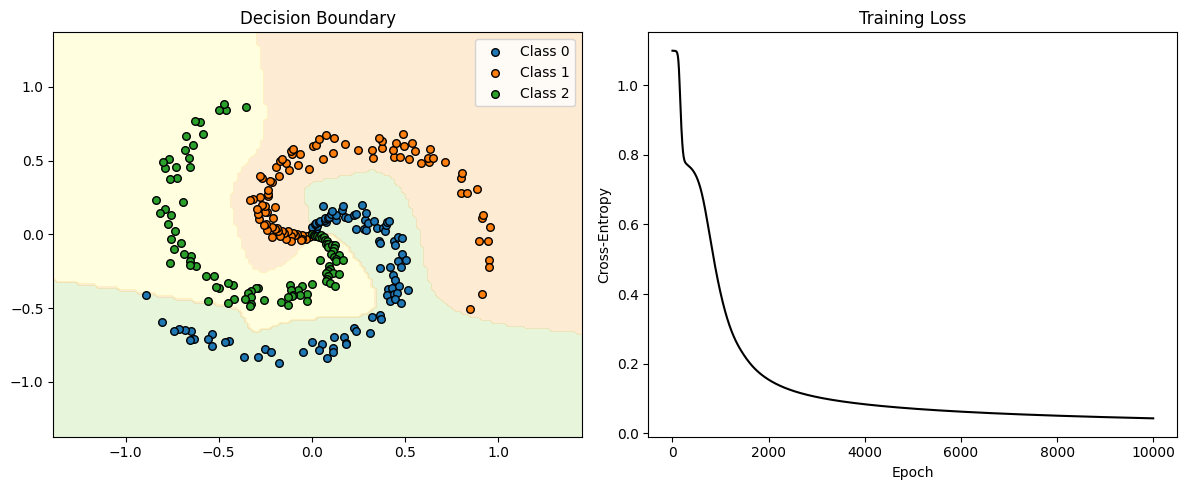

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Make synthetic 3-class data ---
np.random.seed(0)

N = 100  # points per class
D = 2    # dimensionality
K = 3    # number of classes

X = np.zeros((D, N*K))
Y = np.zeros((K, N*K))

for j in range(K):
    ix = range(N*j, N*(j+1))
    r = np.linspace(0.0,1,N)
    t = np.linspace(j*4,(j+1)*4,N) + np.random.randn(N)*0.2
    X[0, ix] = r * np.sin(t)
    X[1, ix] = r * np.cos(t)
    Y[j, ix] = 1  # one-hot

# --- 2. Network ---
np.random.seed(1)
n_input = D
n_hidden = 10
n_output = K

W1 = 0.01 * np.random.randn(n_hidden, n_input)
b1 = np.zeros((n_hidden, 1))
W2 = 0.01 * np.random.randn(n_output, n_hidden)
b2 = np.zeros((n_output, 1))

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(a):
    return a * (1 - a)

def softmax(z):
    exp_scores = np.exp(z - np.max(z, axis=0, keepdims=True))
    return exp_scores / np.sum(exp_scores, axis=0, keepdims=True)

# --- 3. Training ---
lr = 1.0
epochs = 10000
losses = []

N_samples = X.shape[1]

for epoch in range(epochs):
    # Forward
    Z1 = np.dot(W1, X) + b1
    A1 = sigmoid(Z1)
    Z2 = np.dot(W2, A1) + b2
    Y_hat = softmax(Z2)

    # Loss: cross-entropy
    loss = -np.mean(np.sum(Y * np.log(Y_hat + 1e-8), axis=0))
    losses.append(loss)

    # Backward: output layer
    dZ2 = (Y_hat - Y)  # (K, N)
    dW2 = np.dot(dZ2, A1.T) / N_samples
    db2 = np.mean(dZ2, axis=1, keepdims=True)

    # Backward: hidden layer
    dA1 = np.dot(W2.T, dZ2)
    dZ1 = dA1 * sigmoid_derivative(A1)
    dW1 = np.dot(dZ1, X.T) / N_samples
    db1 = np.mean(dZ1, axis=1, keepdims=True)

    # Update
    W2 -= lr * dW2
    b2 -= lr * db2
    W1 -= lr * dW1
    b1 -= lr * db1

    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.6f}")

# --- 4. Decision boundary plot + loss curve ---
h = 0.02
x_min, x_max = X[0,:].min()-0.5, X[0,:].max()+0.5
y_min, y_max = X[1,:].min()-0.5, X[1,:].max()+0.5

xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
grid = np.c_[xx.ravel(), yy.ravel()].T

# Predict on grid
Z1_grid = np.dot(W1, grid) + b1
A1_grid = sigmoid(Z1_grid)
Z2_grid = np.dot(W2, A1_grid) + b2
Y_grid = softmax(Z2_grid)
predicted_class = np.argmax(Y_grid, axis=0).reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: decision boundary + data points
axes[0].contourf(xx, yy, predicted_class, alpha=0.3, levels=np.arange(K+1)-0.5, cmap=plt.cm.Paired)
for j in range(K):
    ix = np.where(Y[j]==1)[0]
    axes[0].scatter(X[0, ix], X[1, ix], label=f'Class {j}', s=30, edgecolor='k')
axes[0].set_title("Decision Boundary")
axes[0].legend()

# Right: loss curve
axes[1].plot(losses, color='black')
axes[1].set_title("Training Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Cross-Entropy")

plt.tight_layout()
plt.show()

# How TensorFlow and PyTorch Automate Training

**Key idea: Automatic Differentiation**

Both TensorFlow and PyTorch use **automatic differentiation (autograd)**.

- **PyTorch:** Dynamic computation graph — built on-the-fly during the forward pass.
- **TensorFlow:** Static or dynamic graphs — uses `tf.function` or eager mode.

In both:
- When you call operations like `y = W @ x + b` they **record** the operations.
- When you call `.backward()` or `tape.gradient()`, the framework **traces the chain rule automatically**.

**Layers and Parameters**

- You define models using `nn.Module` (PyTorch) or `tf.keras.Model` (TensorFlow).
- Layers (`Linear`, `Conv2D`, etc.) manage weights and biases internally.
- Parameters are stored and **tracked** for gradients automatically.

**Loss Function**

- Loss functions like **cross-entropy**, **MSE**, etc. are built-in.
- You just call `loss_fn(y_pred, y_true)` — they handle the sum, mean, and numerically stable formulas.

**Optimizer**

- You do **not** write update rules by hand.
- You wrap parameters in an optimizer (`torch.optim.SGD` or `tf.keras.optimizers.SGD`).
- Call `optimizer.step()` (PyTorch) or `optimizer.apply_gradients()` (TF).
- The framework does:  
  - Compute gradients with `.backward()` or `tape.gradient()`
  - Store them in each parameter
  - Update each parameter using the optimizer’s rule.

**Typical Training Loop**

- **Forward pass:** Model predicts output.
- **Compute loss:** Use a built-in loss.
- **Backward pass:** Compute gradients with `.backward()` (PyTorch) or `tf.GradientTape` (TF).
- **Optimizer step:** Adjust weights.
- **Zero gradients:** Required in PyTorch (`optimizer.zero_grad()`); TensorFlow handles this per step.

**Result**

You write **high-level code**, and the framework:
- Builds the computation graph.
- Tracks all operations for backprop.
- Stores gradients.
- Updates parameters.
- Runs efficiently on CPU or GPU automatically.

This makes training large deep networks feasible without manual derivatives.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Set device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Data Loading and Preprocessing
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert PIL Image to Tensor (0-255 → 0-1)
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST mean and std
])

# Download datasets
train_dataset = datasets.MNIST(
    root='./data', 
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    transform=transform
)

# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1000,
    shuffle=False
)

# 2. Neural Network Architecture
class MNISTClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        # Input: 28x28 = 784 pixels
        self.fc1 = nn.Linear(784, 128)  # Fully connected layer 1
        self.fc2 = nn.Linear(128, 64)   # Fully connected layer 2
        self.fc3 = nn.Linear(64, 10)    # Output layer (10 classes)
        self.relu = nn.ReLU()            # Activation function
        self.dropout = nn.Dropout(0.3)   # Regularization

    def forward(self, x):
        # Flatten image from [batch, 1, 28, 28] to [batch, 784]
        x = x.view(-1, 784)
        
        # Forward pass through layers
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)  # No activation on output (handled in loss)
        return x

# Initialize model and send to device
model = MNISTClassifier().to(device)

# 3. Loss Function and Optimizer
criterion = nn.CrossEntropyLoss()  # Combines LogSoftmax + NLLLoss
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 4. Training Function
def train(epoch):
    model.train()  # Set training mode
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        
        optimizer.zero_grad()  # Clear gradients
        output = model(data)    # Forward pass
        loss = criterion(output, target)  # Calculate loss
        loss.backward()         # Backpropagation
        optimizer.step()        # Update weights
        
        # Print progress every 100 batches
        if batch_idx % 100 == 0:
            print(f'Train Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)} '
                  f'({100. * batch_idx / len(train_loader):.0f}%)]\tLoss: {loss.item():.6f}')

# 5. Testing Function
def test():
    model.eval()  # Set evaluation mode
    test_loss = 0
    correct = 0
    
    with torch.no_grad():  # Disable gradient calculation
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += criterion(output, target).item()  # Sum batch losses
            pred = output.argmax(dim=1, keepdim=True)  # Get predicted class
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(test_loader.dataset)
    accuracy = 100. * correct / len(test_loader.dataset)
    
    print(f'\nTest set: Average loss: {test_loss:.4f}, Accuracy: {correct}/{len(test_loader.dataset)} '
          f'({accuracy:.2f}%)\n')
    return accuracy

# 6. Training Loop
epochs = 10
best_accuracy = 0.0

for epoch in range(1, epochs + 1):
    train(epoch)
    accuracy = test()
    
    # Save best model
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        torch.save(model.state_dict(), 'mnist_model.pth')

print(f"Best accuracy: {best_accuracy:.2f}%")

# 7. Inference Example (after training)
def predict(image):
    model.eval()
    with torch.no_grad():
        image = image.to(device).unsqueeze(0)  # Add batch dimension
        output = model(image)
        probabilities = torch.softmax(output, dim=1)
        confidence, prediction = torch.max(probabilities, 1)
        return prediction.item(), confidence.item()

# Example usage:
# test_image, _ = test_dataset[0]
# pred, conf = predict(test_image)
# print(f"Predicted: {pred} with confidence {conf:.2%}")